<a href="https://colab.research.google.com/github/mrsaeedalharbl-ux/Lab-0.01/blob/main/Copy_of_(Coordination_Chemistry_Simulator_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"""
Crystal Field Theory Simulator
--------------------------------
An interactive tool to simulate d-orbital splitting and predict
UV-Vis absorption colors for transition metal complexes.

Developed with the assistance of AI (used for code structure,
debugging, and expanding the ligand/metal database).
Scientific parameters (f, g factors) are based on Jørgensen's
spectrochemical series and should be verified against a primary
reference (e.g. Lever, "Inorganic Electronic Spectroscopy") before
use in formal academic work.
"""


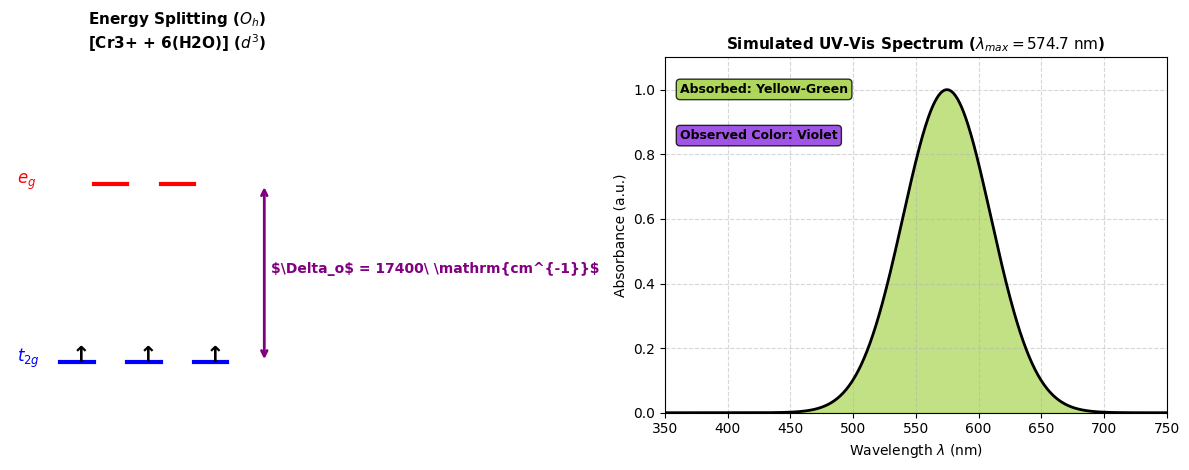

📊 Summary Results:
 • Energy Splitting Δ = 17400 cm⁻¹ (208.1 kJ/mol)
 • CFSE = -1.2 Δ (-249.7 kJ/mol)
 • Predicted Peak λ_max = 574.7 nm | Observed Color: Violet


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from IPython.display import display, clear_output

# ==========================================
# 1. Databases and spectrochemical parameters (Jørgensen)
# ==========================================
# f: ligand factor — reflects the strength of the crystal field
LIGANDS = {
    # --- Very strong field ---
    "Cyanide (CN-)":         {"f": 1.70, "key": "CN-"},
    # --- Amines and polydentate (chelating) ligands ---
    "Bipyridine (bipy)":     {"f": 1.33, "key": "bipy"},
    "Ethylenediamine (en)":  {"f": 1.28, "key": "en"},
    "Ammonia (NH3)":         {"f": 1.25, "key": "NH3"},
    "EDTA":                  {"f": 1.20, "key": "EDTA"},
    # --- Medium field ---
    "Oxalate (C2O4 2-)":     {"f": 0.99, "key": "ox"},
    "Water (H2O)":           {"f": 1.00, "key": "H2O"},
    "Carbonate (CO3 2-)":    {"f": 0.90, "key": "CO3"},
    "Fluoride (F-)":         {"f": 0.90, "key": "F-"},
    "Hydroxide (OH-)":       {"f": 0.94, "key": "OH-"},
    # --- Weak field ---
    "Thiocyanate (SCN-, N)": {"f": 0.75, "key": "SCN-"},
    "Chloride (Cl-)":        {"f": 0.78, "key": "Cl-"},
    "Bromide (Br-)":         {"f": 0.72, "key": "Br-"},
    "Iodide (I-)":           {"f": 0.75, "key": "I-"}
}

# g: metal factor — reflects the metal's charge and number of d electrons
METALS = {
    # --- First-row transition metals ---
    "Titanium(III) [Ti3+]": {"g": 20.3, "d": 1, "key": "Ti3+"},
    "Vanadium(III) [V3+]":  {"g": 18.6, "d": 2, "key": "V3+"},
    "Vanadium(II) [V2+]":   {"g": 12.0, "d": 3, "key": "V2+"},
    "Chromium(III) [Cr3+]": {"g": 17.4, "d": 3, "key": "Cr3+"},
    "Manganese(II) [Mn2+]": {"g": 8.0,  "d": 5, "key": "Mn2+"},
    "Iron(III) [Fe3+]":     {"g": 14.0, "d": 5, "key": "Fe3+"},
    "Iron(II) [Fe2+]":      {"g": 10.0, "d": 6, "key": "Fe2+"},
    "Cobalt(III) [Co3+]":   {"g": 19.0, "d": 6, "key": "Co3+"},
    "Cobalt(II) [Co2+]":    {"g": 9.0,  "d": 7, "key": "Co2+"},
    "Nickel(II) [Ni2+]":    {"g": 8.7,  "d": 8, "key": "Ni2+"},
    "Copper(II) [Cu2+]":    {"g": 12.0, "d": 9, "key": "Cu2+"}
}

# ==========================================
# 2. Coordination chemistry calculation functions
# ==========================================
def calculate_cfse(d_electrons, spin="High", geometry="Octahedral"):
    if geometry == "Octahedral":
        if spin == "High" or d_electrons in [1, 2, 3, 8, 9, 10]:
            if d_electrons <= 3: t2g, eg = d_electrons, 0
            elif d_electrons <= 5: t2g, eg = 3, d_electrons - 3
            elif d_electrons <= 8: t2g, eg = d_electrons - 2, 2
            else: t2g, eg = 6, d_electrons - 6
        else: # Low Spin
            if d_electrons <= 6: t2g, eg = d_electrons, 0
            else: t2g, eg = 6, d_electrons - 6
        cfse = (-0.4 * t2g) + (0.6 * eg)
        return t2g, eg, cfse
    else: # Tetrahedral (Inverted levels e & t2)
        if d_electrons <= 2: eg, t2g = d_electrons, 0
        elif d_electrons <= 5: eg, t2g = 2, d_electrons - 2
        elif d_electrons <= 7: eg, t2g = d_electrons - 3, 3
        else: eg, t2g = 4, d_electrons - 4
        cfse = (-0.6 * eg) + (0.4 * t2g)
        return t2g, eg, cfse

def get_complementary_color(wavelength_nm):
    if 380 <= wavelength_nm < 435: return "Violet", "Yellow-Green", "#8A2BE2", "#ADFF2F"
    elif 435 <= wavelength_nm < 480: return "Blue", "Orange", "#0000FF", "#FFA500"
    elif 480 <= wavelength_nm < 490: return "Greenish Blue", "Orange-Red", "#00CED1", "#FF7F50"
    elif 490 <= wavelength_nm < 500: return "Blue-Green", "Red", "#008080", "#FF0000"
    elif 500 <= wavelength_nm < 560: return "Green", "Purple / Red-Violet", "#008000", "#800080"
    elif 560 <= wavelength_nm < 580: return "Yellow-Green", "Violet", "#9ACD32", "#8A2BE2"
    elif 580 <= wavelength_nm < 595: return "Yellow", "Dark Blue", "#FFFF00", "#00008B"
    elif 595 <= wavelength_nm < 650: return "Orange", "Cyan / Light Blue", "#FFA500", "#00BFFF"
    elif 650 <= wavelength_nm <= 780: return "Red", "Cyan", "#FF0000", "#00FFFF"
    else: return "UV / IR", "Colorless", "#888888", "#F5F5F5"

# ==========================================
# 3. Simulation and spectrum plotting function
# ==========================================
def run_full_simulation(metal_name, ligand_name, spin, geometry):
    clear_output(wait=True)

    metal = METALS[metal_name]
    ligand = LIGANDS[ligand_name]

    delta_o_cm = ligand["f"] * metal["g"] * 1000
    if geometry == "Tetrahedral":
        delta_cm = (4/9) * delta_o_cm
        geo_symbol = "T_d"
    else:
        delta_cm = delta_o_cm
        geo_symbol = "O_h"

    delta_kj = delta_cm * 0.01196
    lambda_max = 1e7 / delta_cm

    t2g, eg, cfse_factor = calculate_cfse(metal["d"], spin, geometry)
    cfse_kj = cfse_factor * delta_kj

    abs_color, comp_color, abs_hex, comp_hex = get_complementary_color(lambda_max)
    coord_num = 4 if geometry == "Tetrahedral" else 6
    complex_formula = f"[{metal['key']} + {coord_num}({ligand['key']})]"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={'width_ratios': [1.2, 1.8]})

    ax1.set_title(fr"Energy Splitting (${geo_symbol}$)" + "\n" + f"{complex_formula} ($d^{{{metal['d']}}}$)", fontsize=11, fontweight='bold')
    ax1.set_xlim(0, 5)
    ax1.set_ylim(-2, 5)
    ax1.axis('off')

    if geometry == "Octahedral":
        y_low, y_high = -1.0, 2.5
        low_x, high_x = [1.0, 2.0, 3.0], [1.5, 2.5]
        low_label, high_label = "$t_{2g}$", "$e_g$"
        low_count, high_count = t2g, eg
        low_color, high_color = 'blue', 'red'
    else:
        y_low, y_high = -1.0, 2.5
        low_x, high_x = [1.5, 2.5], [1.0, 2.0, 3.0]
        low_label, high_label = "$e$", "$t_2$"
        low_count, high_count = eg, t2g
        low_color, high_color = 'red', 'blue'

    for x in low_x: ax1.plot([x-0.25, x+0.25], [y_low, y_low], color=low_color, lw=3)
    for x in high_x: ax1.plot([x-0.25, x+0.25], [y_high, y_high], color=high_color, lw=3)

    ax1.text(0.1, y_low, low_label, fontsize=12, fontweight='bold', color=low_color)
    ax1.text(0.1, y_high, high_label, fontsize=12, fontweight='bold', color=high_color)

    ax1.annotate('', xy=(3.8, y_high), xytext=(3.8, y_low), arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
    delta_label = fr"$\Delta_t$" if geometry == "Tetrahedral" else fr"$\Delta_o$"
    ax1.text(3.9, 0.75, fr"{delta_label} = {delta_cm:.0f}\ \mathrm{{cm^{{-1}}}}$", fontsize=10, color='purple', fontweight='bold')

    for i in range(low_count):
        x = low_x[i % len(low_x)]
        ax1.annotate('↑' if i < len(low_x) else '↓', xy=(x - (0.08 if i < len(low_x) else -0.04), y_low), fontsize=16, fontweight='bold')
    for i in range(high_count):
        x = high_x[i % len(high_x)]
        ax1.annotate('↑' if i < len(high_x) else '↓', xy=(x - (0.08 if i < len(high_x) else -0.04), y_high), fontsize=16, fontweight='bold')

    ax2.set_title(fr"Simulated UV-Vis Spectrum ($\lambda_{{max}} = {lambda_max:.1f}\ \mathrm{{nm}}$)", fontsize=11, fontweight='bold')

    wavelengths = np.linspace(350, 750, 500)
    sigma = 35
    absorbance = np.exp(-((wavelengths - lambda_max)**2) / (2 * sigma**2))

    ax2.plot(wavelengths, absorbance, color='black', lw=2, label='Absorbance Spectrum')
    ax2.fill_between(wavelengths, 0, absorbance, color=abs_hex, alpha=0.6)

    ax2.set_xlabel("Wavelength $\lambda$ (nm)", fontsize=10)
    ax2.set_ylabel("Absorbance (a.u.)", fontsize=10)
    ax2.set_xlim(350, 750)
    ax2.set_ylim(0, 1.1)
    ax2.grid(True, linestyle='--', alpha=0.5)

    ax2.text(0.03, 0.90, f"Absorbed: {abs_color}", transform=ax2.transAxes, bbox=dict(boxstyle='round', facecolor=abs_hex, alpha=0.8), fontsize=9, fontweight='bold', color='white' if abs_color in ['Blue', 'Green', 'Purple / Red-Violet'] else 'black')
    ax2.text(0.03, 0.77, f"Observed Color: {comp_color}", transform=ax2.transAxes, bbox=dict(boxstyle='round', facecolor=comp_hex, alpha=0.8), fontsize=9, fontweight='bold', color='white' if comp_color in ['Dark Blue', 'Purple / Red-Violet', 'Blue'] else 'black')

    plt.tight_layout()
    plt.show()

    print(f"📊 Summary Results:")
    print(f" • Energy Splitting Δ = {delta_cm:.0f} cm⁻¹ ({delta_kj:.1f} kJ/mol)")
    print(f" • CFSE = {cfse_factor:.1f} Δ ({cfse_kj:.1f} kJ/mol)")
    print(f" • Predicted Peak λ_max = {lambda_max:.1f} nm | Observed Color: {comp_color}")

# ==========================================
# 4. Interactive control interface
# ==========================================
metal_w = widgets.Dropdown(options=list(METALS.keys()), value="Chromium(III) [Cr3+]", description="الفلز:")
ligand_w = widgets.Dropdown(options=list(LIGANDS.keys()), value="Water (H2O)", description="الليجاند:")
spin_w = widgets.RadioButtons(options=["High", "Low"], value="High", description="الغزل:")
geo_w = widgets.ToggleButtons(options=["Octahedral", "Tetrahedral"], value="Octahedral", description="الهندسة:")

ui = widgets.interactive(run_full_simulation, metal_name=metal_w, ligand_name=ligand_w, spin=spin_w, geometry=geo_w)
display(ui)
